# BI-Projekt: Veloverkehr in Zürich

## 1 - Datenakquisition & erste Exploration

Dieses Notebook lädt die Kerndatensätze herunter und führt eine erste Sichtung durch.

**Datenquellen:**
- Velozählstellen Zürich (15-Min, data.stadt-zuerich.ch)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (14, 6)

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

print('Setup OK')

Setup OK


---
## 1.1 Zürich - Velo-/Fussgängerzählungen (15-Min)

In [2]:
# Download Zürich data - one CSV per year
# Available from 2009-2026 at data.stadt-zuerich.ch
ZH_BASE = 'https://data.stadt-zuerich.ch/dataset/ted_taz_verkehrszaehlungen_werte_fussgaenger_velo/download'
ZH_YEARS = range(2020, 2026)  # start with recent years; extend to 2009 if needed

for year in ZH_YEARS:
    fname = f'{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv'
    fpath = DATA_DIR / fname
    if not fpath.exists():
        url = f'{ZH_BASE}/{fname}'
        print(f'Downloading {fname} ...')
        r = requests.get(url, timeout=120)
        r.raise_for_status()
        fpath.write_bytes(r.content)
        print(f'  -> {fpath} ({len(r.content) / 1e6:.1f} MB)')
    else:
        print(f'{fname} already exists')

2020_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists
2021_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists
2022_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists
2023_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists
2024_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists
2025_verkehrszaehlungen_werte_fussgaenger_velo.csv already exists


In [3]:
# Load and concatenate Zürich data
zh_frames = []
for year in ZH_YEARS:
    fname = f'{year}_verkehrszaehlungen_werte_fussgaenger_velo.csv'
    df = pd.read_csv(DATA_DIR / fname)
    zh_frames.append(df)
    print(f'{year}: {len(df):>10,} rows, columns: {list(df.columns)}')

zh = pd.concat(zh_frames, ignore_index=True)
print(f'\nTotal Zürich: {len(zh):,} rows')
zh.head()

2020:  1,257,695 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2021:  1,178,570 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2022:  1,189,238 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2023:    949,660 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2024:    918,683 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']


2025:    853,565 rows, columns: ['FK_STANDORT', 'DATUM', 'VELO_IN', 'VELO_OUT', 'FUSS_IN', 'FUSS_OUT', 'OST', 'NORD']

Total Zürich: 6,347,411 rows


,FK_STANDORT,DATUM,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
0,3927,2020-01-01T00:00,1.0,1.0,NaN,NaN,2682873,1245891
1,2977,2020-01-01T00:00,1.0,NaN,NaN,NaN,2682681,1250570
2,3923,2020-01-01T00:00,0.0,0.0,NaN,NaN,2681385,1247736
3,2979,2020-01-01T00:00,0.0,0.0,NaN,NaN,2681858,1251991
4,60,2020-01-01T00:00,0.0,0.0,NaN,NaN,2682731,1247708


In [4]:
zh.info()
print('\n--- Descriptive Stats ---')
zh.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6347411 entries, 0 to 6347410
Data columns (total 8 columns):
 #   Column       Dtype  
---  ------       -----  
 0   FK_STANDORT  int64  
 1   DATUM        str    
 2   VELO_IN      float64
 3   VELO_OUT     float64
 4   FUSS_IN      float64
 5   FUSS_OUT     float64
 6   OST          int64  
 7   NORD         int64  
dtypes: float64(4), int64(3), str(1)
memory usage: 484.3 MB

--- Descriptive Stats ---


,FK_STANDORT,VELO_IN,VELO_OUT,FUSS_IN,FUSS_OUT,OST,NORD
count,6.347411e+06,4.499675e+06,3.926686e+06,1.854072e+06,1.854072e+06,6.347411e+06,6.347411e+06
mean,2.993860e+03,9.625092e+00,6.051418e+00,1.457134e+01,1.221276e+01,2.682510e+06,1.248489e+06
std,1.235721e+03,1.462709e+01,8.680143e+00,2.182167e+01,1.860218e+01,1.083600e+03,1.977933e+03
min,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.678956e+06,1.244136e+06
25%,2.978000e+03,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,2.682227e+06,1.247199e+06
50%,2.998000e+03,4.000000e+00,3.000000e+00,6.000000e+00,5.000000e+00,2.682731e+06,1.248328e+06
75%,4.242000e+03,1.200000e+01,9.000000e+00,2.000000e+01,1.700000e+01,2.683404e+06,1.249212e+06
max,5.004000e+03,1.086000e+03,6.870000e+02,6.860000e+02,6.620000e+02,2.684578e+06,1.253280e+06


---
## 1.2 Quick Visual Check - Zürich Velo Counts

In [5]:
# Zürich columns: FK_STANDORT, DATUM, VELO_IN, VELO_OUT, FUSS_IN, FUSS_OUT, OST, NORD
zh['date'] = pd.to_datetime(zh['DATUM'], errors='coerce')
zh['VELO_IN'] = pd.to_numeric(zh['VELO_IN'], errors='coerce')
zh['VELO_OUT'] = pd.to_numeric(zh['VELO_OUT'], errors='coerce')
zh['velo_total'] = zh['VELO_IN'].fillna(0) + zh['VELO_OUT'].fillna(0)
print(f'Date range: {zh["date"].min()} - {zh["date"].max()}')
print(f'Counting stations: {zh["FK_STANDORT"].nunique()}')

Date range: 2020-01-01 00:00:00 - 2025-12-31 23:45:00
Counting stations: 83


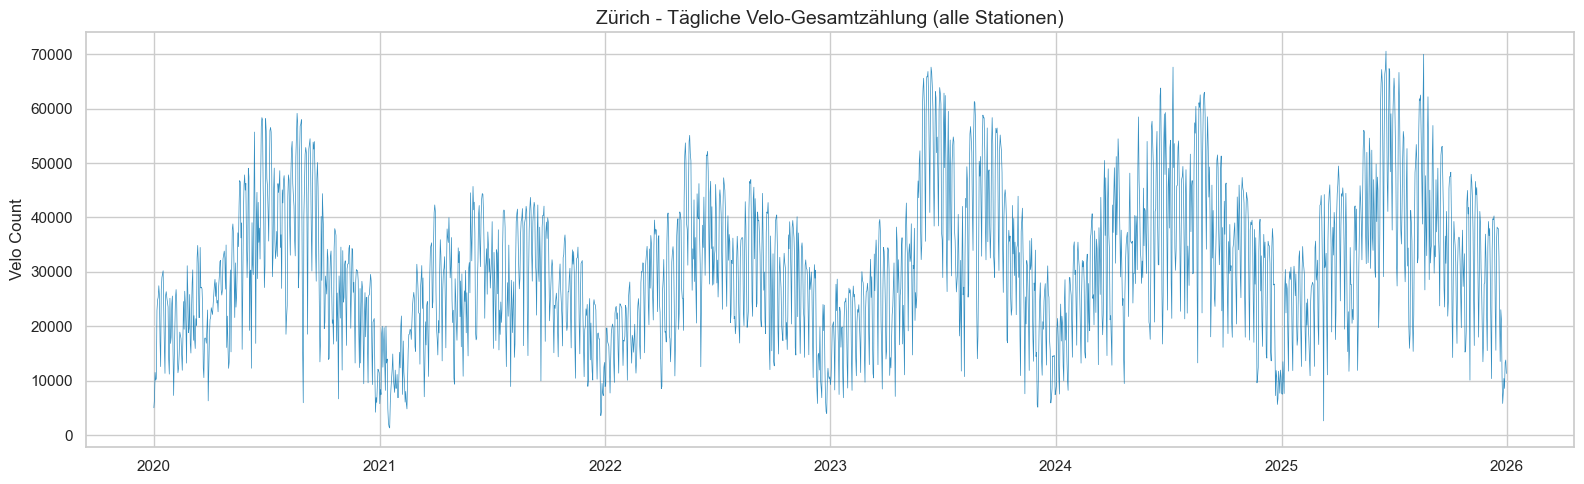

In [6]:
# Daily total velo counts across all stations
daily = zh.groupby(zh['date'].dt.date)['velo_total'].sum()

fig, ax = plt.subplots(figsize=(16, 5))
daily.plot(ax=ax, linewidth=0.5, alpha=0.8)
ax.set_title('Zürich - Tägliche Velo-Gesamtzählung (alle Stationen)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Velo Count')
plt.tight_layout()
plt.show()

---
## 1.3 Data Summary

| Dataset | Rows | Time Range | Granularity |
|---------|------|-----------|-------------|
| Zürich  | *see above* | 2020-2025 | 15 min |

### Next Steps (Notebook 02)
- Data cleaning & type conversion
- Filter for Velo-only records (exclude pedestrian counts)
- Temporal feature engineering (hour, weekday, month, season)
- Sensor-Ausfall-Erkennung und Stationskonsistenz-Analyse